# 1. BUSINESS CASE & PROBLEM DEFINITION

## 1.2 BUSINESS UNDERSTANDING  
La rentabilidad de un hotel depende directamente del nivel de ocupación real, es decir, del número de reservas que finalmente se materializan. Sin embargo, una proporción significativa de las reservas termina en cancelaciones. Cuando estas cancelaciones no se compensan con nuevas reservas en un periodo razonable, el hotel pierde ingresos y reduce su eficiencia operativa.

El objetivo de negocio es anticipar qué reservas tienen mayor probabilidad de cancelarse para permitir al hotel tomar decisiones más inteligentes. Con esta información, el equipo de Revenue Management y el departamento de Reservas podrán:

- aplicar estrategias de overbooking controlado,

- ajustar precios de forma dinámica,

- mejorar la comunicación con clientes de alto riesgo,

- adaptar las políticas de cancelación según el perfil de la reserva.

El modelo permitirá minimizar el impacto negativo de las cancelaciones, optimizar la ocupación y mejorar la rentabilidad sin perjudicar la experiencia del cliente.

## 1.2 ML OBJECTIVE
El problema se traduce en un objetivo de Machine Learning claro:

**Tipo de problema:** *Clasificación binaria*

***Variable target:** *is_canceled*

**Clases:**

- 0 → Reserva que llega a término

- 1 → Reserva cancelada

Métricas adecuadas según la guía
Dado que el dataset está desbalanceado, las métricas recomendadas son:
F1-score, Recall (especialmente importante si queremos detectar cancelaciones), Precision, ROC-AUC

Dado que el coste de no detectar una cancelación es mayor que el de una falsa alarma, se priorizará el Recall y el F1-score sobre el Accuracy.

## 1.3 ACTION PLAN

En función de la predicción del modelo:

- Si la reserva tiene alta probabilidad de cancelarse:

- activar estrategias de overbooking controlado,

- enviar comunicaciones preventivas al cliente,

- ajustar precios dinámicamente,

- aplicar políticas de cancelación más estrictas.

Si la probabilidad es baja:

- mantener condiciones estándar,

- priorizar la reserva en caso de alta demanda.

**Umbral mínimo de rendimiento**

El modelo se considerará útil si alcanza un ROC-AUC ≥ 0.75 y un Recall ≥ 0.70 en la clase de cancelación.

**Datos y licencia**
Dataset: Hotel Booking Demand (Kaggle)
Accesible: Sí
Licencia: Open Data (uso permitido para proyectos educativos)

# 2. DATA UNDERSTANDING

## 2.1 FIRST LOOK

In [13]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv('src/data_sample/hotel_bookings.csv')

### Target `is_canceled`  valores 1 cuando la reserva es cancelada y 0 cuando no

In [15]:
print(f"Shape: {df.shape}")
df.info()
df.describe(include='all')
(df.isnull().mean() * 100).sort_values(ascending=False).round(1)

Shape: (119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 

company                           94.3
agent                             13.7
country                            0.4
children                           0.0
arrival_date_month                 0.0
arrival_date_week_number           0.0
hotel                              0.0
is_canceled                        0.0
stays_in_weekend_nights            0.0
arrival_date_day_of_month          0.0
adults                             0.0
stays_in_week_nights               0.0
babies                             0.0
meal                               0.0
lead_time                          0.0
arrival_date_year                  0.0
distribution_channel               0.0
market_segment                     0.0
previous_bookings_not_canceled     0.0
is_repeated_guest                  0.0
reserved_room_type                 0.0
assigned_room_type                 0.0
booking_changes                    0.0
previous_cancellations             0.0
deposit_type                       0.0
days_in_waiting_list     

Porcentaje de nulos por columna:  
children = 0.003%  
country = 0.409%  
agent = 13.686%  
company = 94.306%  

## 2.2 DATA DICTIONARY

La columna `reservation_status` contiene valores equivalentes al target.  
Por otro lado, la columna `reservation_status_date` representa la fecha en la que se registró el estado final de la reserva (cancelación, check-out o no-show). Esta información solo existe después de que la reserva ya ha concluido, por lo que no está disponible en el momento en que queremos predecir si una reserva será cancelada. Usarla introduciría fuga de información (data leakage), ya que el modelo aprendería patrones derivados del resultado final de la reserva.  
En tercer lugar también se descartarían aquellas columnas cuyo porcentaje de nulos sobrepasa el 80% `descartable_null`

In [31]:
df[['reservation_status', 'is_canceled']].groupby('reservation_status').mean()

,is_canceled
reservation_status,
Canceled,1.0
Check-Out,0.0
No-Show,1.0


#### Importancia preliminar de las variables (Valoración inicial)

**Variables con alta aportación esperada**  
- `lead_time`: las reservas con mucha antelación se suelen cancelar más  
- `adr`: 'Tarifa media Diaria' El precio influye en la probabiliad de cancelación  
- `deposit_type`: los depósitos no reembonsables reducen cancelaciones
- `previous_cancellations`: comportamiento histórico del cliente
- `previous_bookings_not_canceled`: Número de reservas anteriores no canceladas por el cliente antes de la reserva actual
- `total_of_special_requests`: los clientes con más requisitos cancelan menos  
- `booking_changes`: Número de modificaciones de la reserva, hasta el check-in o cancelación

**Variables con aportación media**
- `agent`: algunas agencias tienen tasas de cancelación distintas
- `market_segments`: algunso segmenos cancelan más (TA =Travel Agents, TO =Tour Operators)
- `customer_type`: familias, parejas o grupos tiene comportamientos distintos
- `hotel`: tipo de hotel  
- `arrival_date_month  `
- `arrival_date_day_of_month`:habrá que valorarlo en el EDA para ver si hay un patrón
- `arrival_date_week_number`:habrá que valorarlo en el EDA para ver si hay un patrón
- `arrival_date_year`: habrá que valorarlo en el EDA para ver si hay un patrón
- `stays_in_weekend_nights`
- `stays_in_week_nights`
- `adults`
- `children`
- `babies`
- `country`  (si no tiene mucha cardinalidad)

**Variable con aportación baja o redundante**
- `assigned_room_type`
- `reserved_room_type`  
- `meal`  
- `is_repeated_guest`
- `required_car_parking_spaces`: Número de plazas de aparcamiento solicitadas por el huésped
- `arrival_date_week_number`: poca relación con cancelación
- `arrival_date_year`: casi no aporta variabilidad

**Variables descartadas**
- `company`: >80% nulos -> no aporta valor
- `reservation_status`: information leakage (coincide con el target)  
- `reservation_status_date`: information leakage. Previamente explicado


In [34]:
leakage_cols = ['reservation_status', 'reservation_status_date']
null_pct = (df.isnull().mean() * 100).round(1)
descartable_null = null_pct > 80
descartable_manual = df.columns.isin(leakage_cols)

descartable = descartable_null | descartable_manual

data_dict = pd.DataFrame({
    'columna': df.columns,
    'dtype': df.dtypes.values,
    'nulos_pct': null_pct.values,
    'unicos': df.nunique().values,
    'ejemplo': [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else None for c in df.columns],
    'valor_modelo': [
        'alta' if col in ['lead_time','adr','deposit_type','previous_cancellations'] else
        'media' if col in ['agent','market_segment','customer_type'] else
        'leakage' if col in ['reservation_status','reservation_status_date'] else
        'irrelevante' if col in ['arrival_date_week_number'] else
        'pendiente'
        for col in df.columns
    ],
    'descartable': descartable.values
})
data_dict

,columna,dtype,nulos_pct,unicos,ejemplo,valor_modelo,descartable
0,hotel,object,0.0,2,Resort Hotel,pendiente,False
1,is_canceled,int64,0.0,2,0,pendiente,False
2,lead_time,int64,0.0,479,342,alta,False
3,arrival_date_year,int64,0.0,3,2015,pendiente,False
4,arrival_date_month,object,0.0,12,July,pendiente,False
5,arrival_date_week_number,int64,0.0,53,27,irrelevante,False
6,arrival_date_day_of_month,int64,0.0,31,1,pendiente,False
7,stays_in_weekend_nights,int64,0.0,17,0,pendiente,False
8,stays_in_week_nights,int64,0.0,35,0,pendiente,False
9,adults,int64,0.0,14,2,pendiente,False


## 2.3 TRAIN-TEST SPLIT

In [36]:
from sklearn.model_selection import train_test_split

TARGET = 'is_canceled'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y  # solo en clasificación
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (95512, 31), Test: (23878, 31)


# 3. EDA DIRIGIDO AL MODELADO

## 3.1 TARGET ANALYSIS

En la gráfica de distribución del target vemos que es de un 37% de cancelaciones y un 63% de reservas no canceladas.  
Si bien es verdad que no es un desbalance severo, si se puede considerar que es un desbalanceo moderado de manera que:  
- Accuracy no sea una métrica fiable,
- SMOTE podría ayudar pero no es obligatorio
- Hacer un Stratify en el split es altamente recomendable (ha se hizo en el split train test)

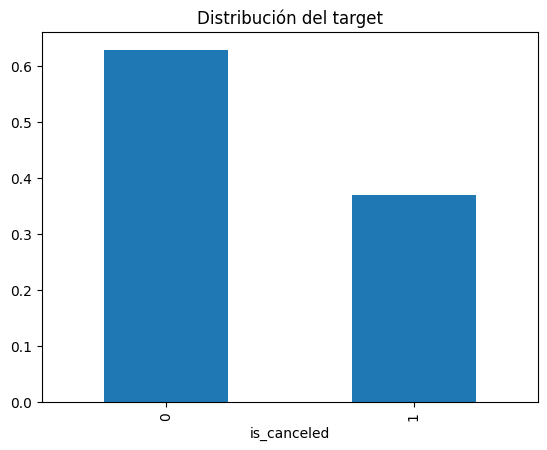

Skewness: 0.54


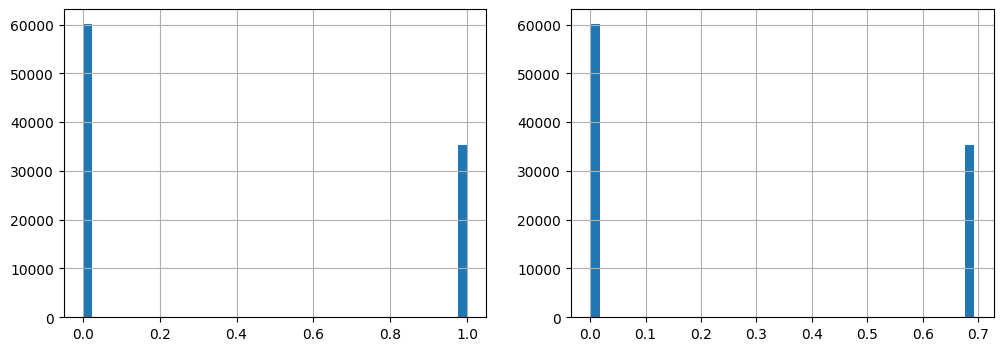

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clasificación: balanceo de clases
y_train.value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución del target'); plt.show()

# Regresión: distribución y asimetría
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.hist(bins=40, ax=axes[0])
np.log1p(y_train).hist(bins=40, ax=axes[1])
print(f"Skewness: {y_train.skew():.2f}")

## 3.2 FEATURE - TARGET RELATIONSHIP

Antes de hacer el análisis multivariante con el target excluimos de las features a analaizar las columnas consideradas poco importantes y sobre todo las que puedan producir leakage como se puede ver en el apartado 2.2

In [41]:
cols_descartables = ['company', 'reservation_status', 'reservation_status_date']

### Numéricas vs. target para problemas de clasifiicación: distribución por clase

In [42]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in cols_descartables]
num_cols


['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=X_train.join(y_train), x=TARGET, y=col)
    plt.title(f'Boxplot of {col} by {TARGET}')
    plt.show()


- Para la variable `lead_time` podemos ver que tiene bastantes outliers, pero también se puede observar que los valores son mayores cuando la reserva es cancelada, es decir a mayor antelación de la reserva más cancelaciones hay  
- Respecto a las variables `adults`, `children`y `babies` vemos que las reservas con niños o bebés suelen ser más estables.  
- Para `is_repeated_guest` se aprecia que los clientes que ya han reservado previamente suelen cancelar menos, así que también es una features últil para el modelo.

### Categóricas vs. target

In [43]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in cols_descartables]
cat_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type']

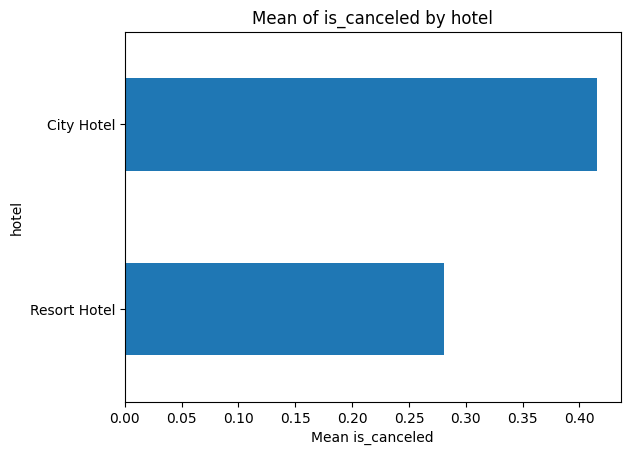

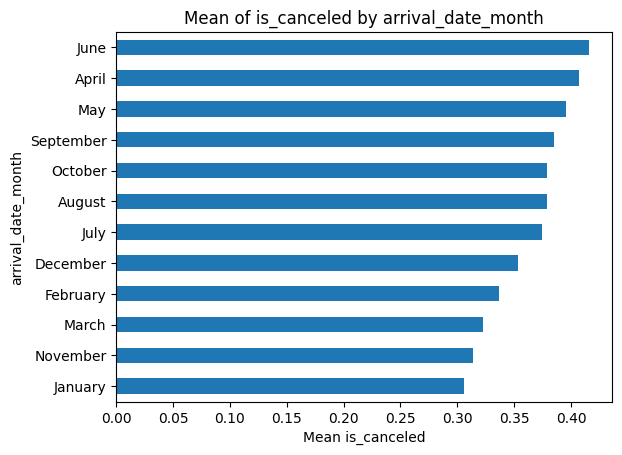

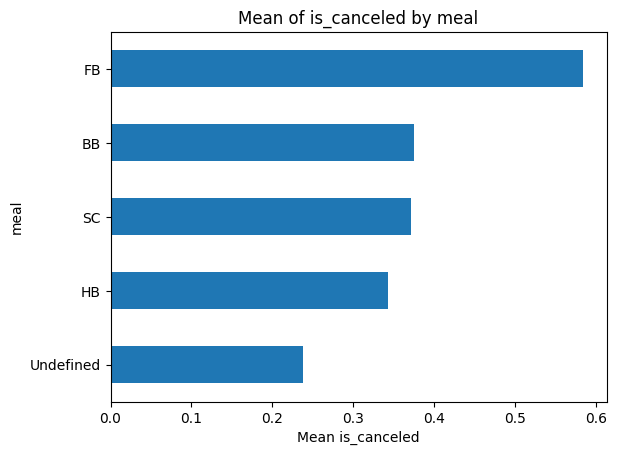

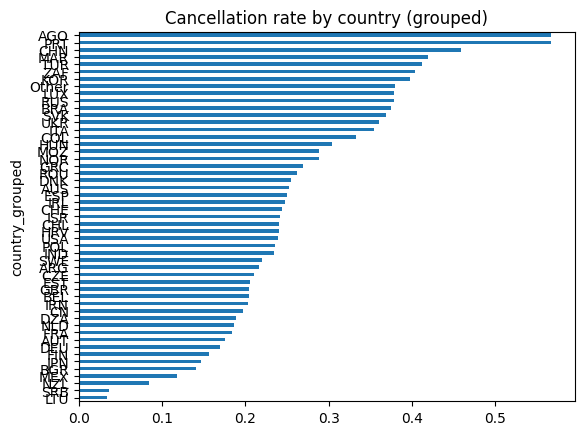

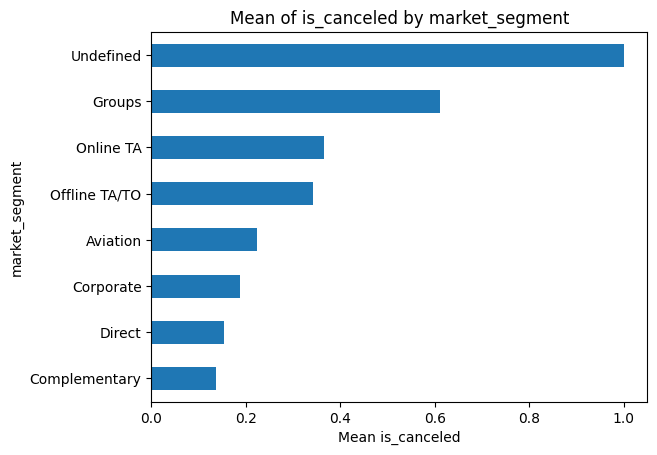

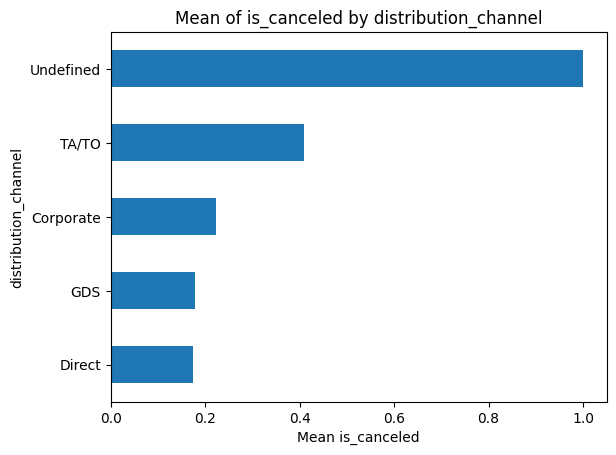

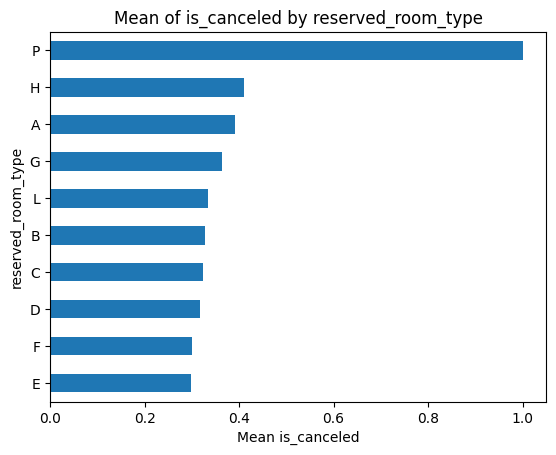

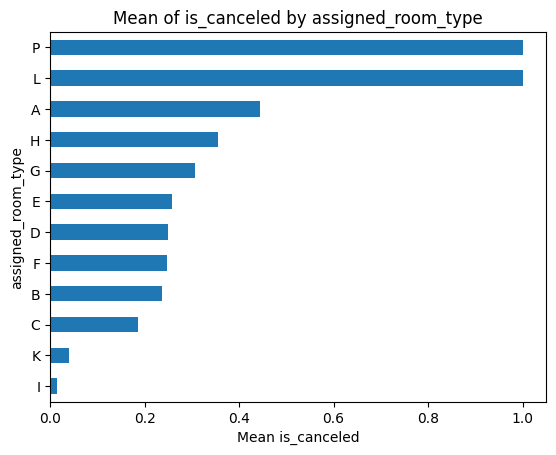

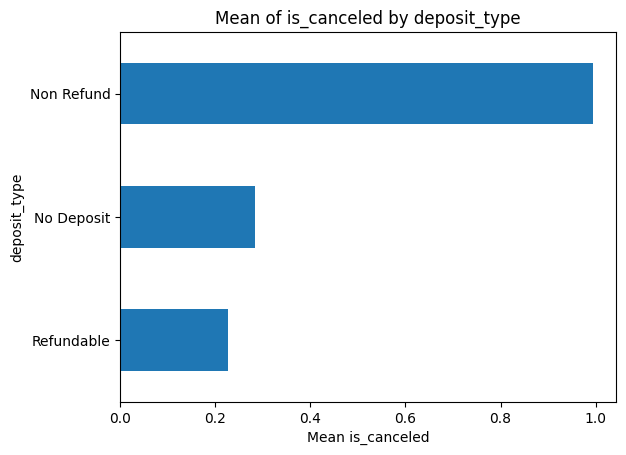

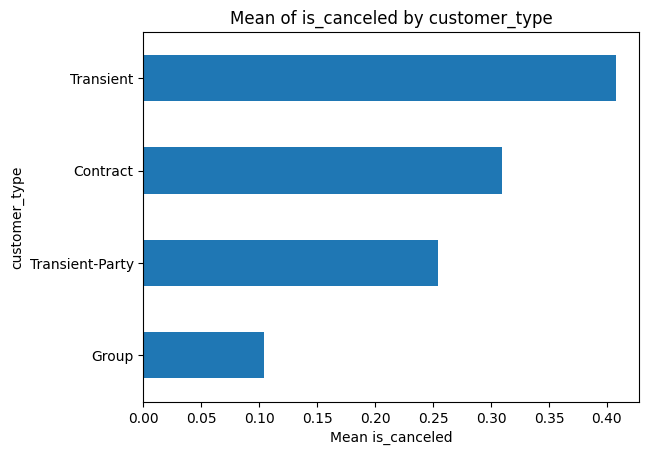

In [87]:
df_ct = X_train.join(y_train).copy()
country_counts = df_ct['country'].value_counts()

rare_countries = country_counts[country_counts < 50].index
df_ct['country_grouped'] = df_ct['country'].replace(rare_countries, 'Other')


for col in cat_cols:
    if col == 'country':
        df_ct.groupby('country_grouped')[TARGET].mean().sort_values().plot(kind='barh')
        plt.title('Cancellation rate by country (grouped)')
    else:
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_values().plot(kind='barh')
        plt.title(f'Mean of {TARGET} by {col}')
        plt.xlabel(f'Mean {TARGET}')
        plt.ylabel(col)
    plt.show()

- Tipo de hotel `hotel`: Las cancelaciones son menos frecuentes en los hoteles de vacaciones (Resort Hotel) que en los hoteles urbanos (City Hotel). Esto sugiere que los clientes que viajan por ocio tienden a cancelar menos que los que viajan por motivos laborales o estancias cortas.
- Mes de llegada `arrival_date_month`: Se observa un ligero aumento de cancelaciones en primavera–verano. No parece un efecto especialmente marcado y podría estar influido por el incremento general de reservas en esos meses.
- Tipo de comida `meal`: Las reservas con modalidad Full Board presentan una mayor proporción de cancelaciones. Esto indica que el tipo de régimen contratado puede influir en el comportamiento del cliente.
- País de origen `country`: El país tiene impacto en la tasa de cancelación: algunos países muestran porcentajes significativamente más altos que otros. Debido a la alta cardinalidad de esta variable, conviene agrupar países con pocas observaciones o analizar únicamente aquellos con suficiente volumen de reservas.
- Segmento de mercado  `market_segment`: La forma de contratar la reserva influye en la probabilidad de cancelación. Además, la distribución de cancelaciones por segmento es similar a la observada en `distribution_channel`, lo que indica que ambas variables están relacionadas y reflejan patrones similares de comportamiento del cliente.
- Tipo de habitación `reserved_room_type` (tipo P) y `assigned_room_type` (tipos L y P) respectivamente,  sufren una gran proporción de cancelaciones. Esto sugiere que el tipo de habitación puede ser un factor determinante en la cancelación.
- Tipo de depósito `deposit_type`: Las reservas clasificadas como Non Refund muestran más cancelaciones, lo cual puede parecer contraintuitivo. Sin embargo, esta variable refleja la política del hotel, no necesariamente el comportamiento del cliente. Las tarifas Non Refund suelen ser más económicas y se reservan con mayor antelación, lo que atrae a clientes con menor compromiso. Por ello, esta variable es relevante para el modelo y está correlada con otras como `lead_time` (alto) y `market_segment`, que explican mejor este patrón.
- Tipo de cliente `customer_type`: El tipo de contrato también influye en la tasa de cancelación. Algunos perfiles de cliente muestran mayor estabilidad que otros, lo que convierte esta variable en un factor potencialmente relevante para el modelo.

### Temporales vs. target

In [ ]:
temp_cols = [
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_week_number',
    'arrival_date_day_of_month'
]


['arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month']

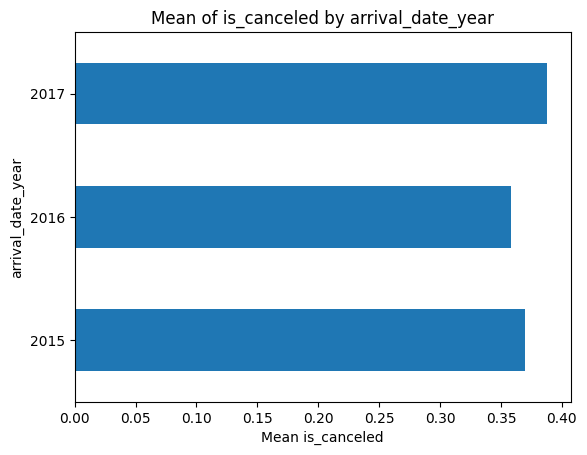

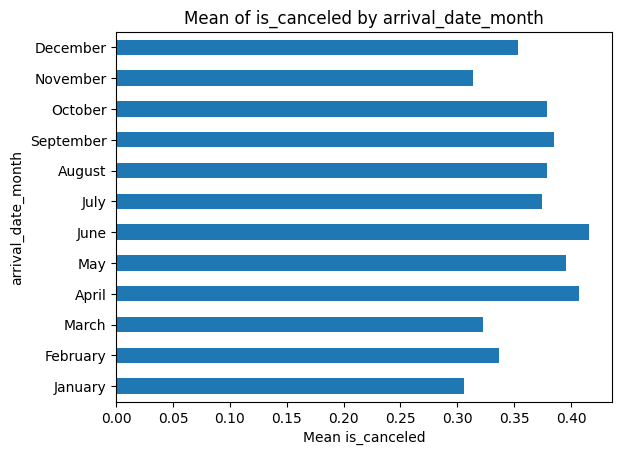

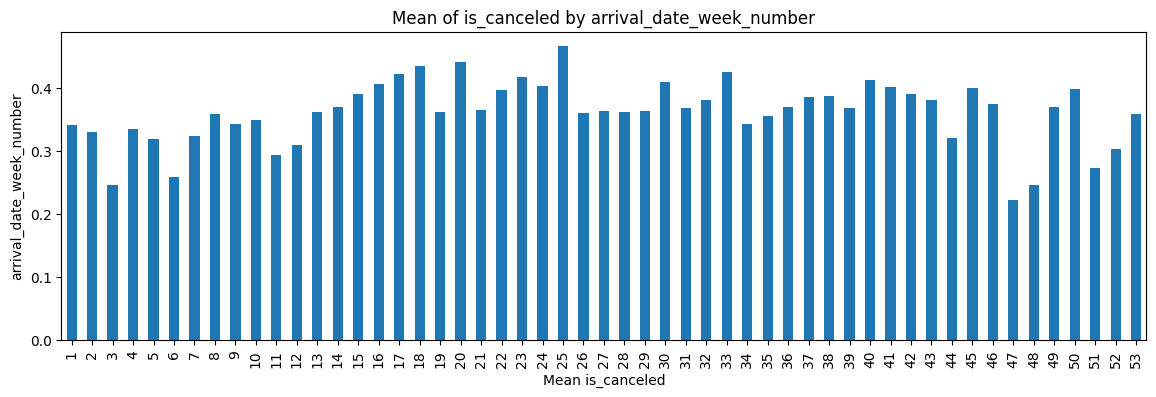

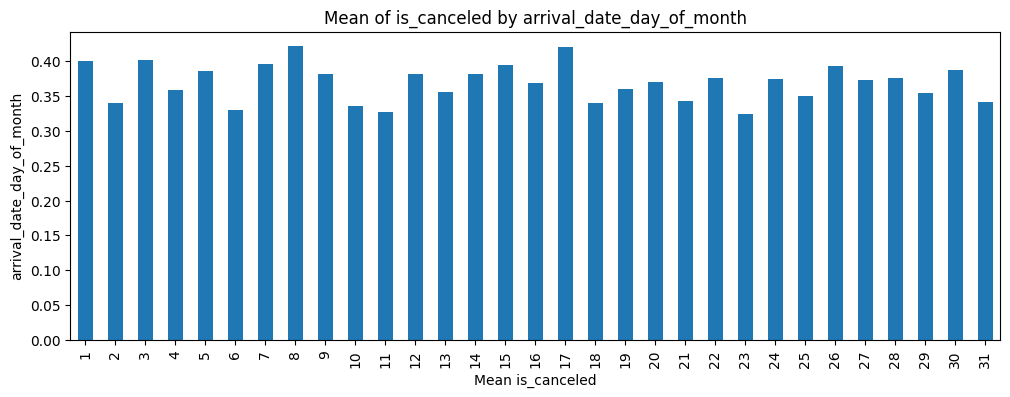

In [93]:

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

for col in temp_cols:    
    if col == 'arrival_date_month':
        X_train.join(y_train).groupby(col)[TARGET].mean().loc[month_order].plot(kind='barh')
    elif col == 'arrival_date_week_number':
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='bar', figsize=(14,4))
    elif col == 'arrival_date_day_of_month':
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='bar', figsize=(12,4))
    else:
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='barh')
    plt.title(f'Mean of {TARGET} by {col}')
    plt.xlabel(f'Mean {TARGET}')
    plt.ylabel(col)
    plt.show()

En conjunto, las variables temporales no muestran patrones fuertes ni independientes que expliquen la cancelación de reservas. Los ligeros aumentos observados en verano parecen estar más relacionados con otros factores (como mayor volumen de reservas y mayor antelación en la planificación) que con el propio componente temporal.

Por tanto, estas variables podrían tener una aportación baja o moderada en el modelo, y su relevancia dependerá de cómo interactúen con otras características como `lead_time`, `market_segment` o `deposit_type`.

## 3.3 MULTICOLLINEARITY & OUTLIERS

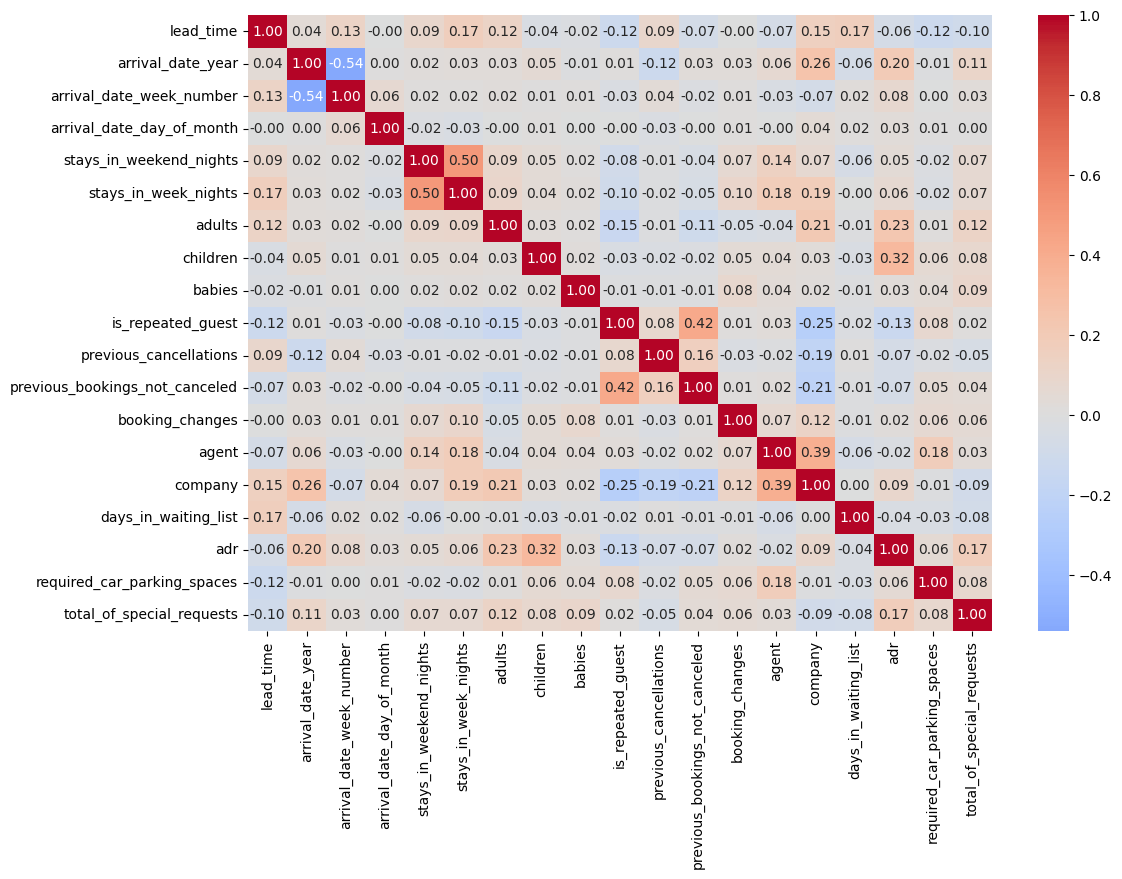

In [94]:
# Heatmap de correlación
corr = X_train.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()



Podemos ver que las variables `is_repeated_guest` y `previous_bookings_not_canceled` son parcialmente redundantes. Por un lado es lógico ya que si un cliente ha tenido reservas previas no canceladas, es más probable que sea un cliente repetidor.  

Por otro lado las variables `stays_in_week_nights` y `stays_in_weekend_nights` también están bastante correladas, ya que quien se queda muchas noches entresemana suele quedarse también los fines de semana. De hecho podrían combinarse en una sola `total_nights`  

También se observa una correlación, pero ligera entre adults y adr, así como entre children y adr. Esto es coherente con el comportamiento habitual del sector hotelero: las reservas con adultos suelen asociarse a tarifas más elevadas, mientras que las reservas con niños tienden a corresponder a habitaciones familiares o paquetes con precios medios más bajos. La variable babies, en cambio, no muestra correlación relevante debido a su baja variabilidad. No es una multicolinealidad fuerte que requiera eliminar ninguna de las variables

In [99]:
for col in num_cols:
# Outliers por IQR
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR))
    print(f"Outliers:{col }  {outliers.sum()}")
    


Outliers:lead_time  2386
Outliers:arrival_date_year  0
Outliers:arrival_date_week_number  0
Outliers:arrival_date_day_of_month  0
Outliers:stays_in_weekend_nights  211
Outliers:stays_in_week_nights  2696
Outliers:adults  23857
Outliers:children  6844
Outliers:babies  710
Outliers:is_repeated_guest  3014
Outliers:previous_cancellations  5171
Outliers:previous_bookings_not_canceled  2887
Outliers:booking_changes  14423
Outliers:agent  0
Outliers:days_in_waiting_list  2966
Outliers:adr  2997
Outliers:required_car_parking_spaces  5906
Outliers:total_of_special_requests  2295


In [107]:
df.children.value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

El análisis de outliers mediante IQR muestra un número elevado de valores marcados como extremos en varias variables.  

Sin embargo, este resultado debe interpretarse con cautela. En variables continuas como `lead_time` y `adr`, los outliers reflejan comportamientos reales del negocio y no representan un problema. En cambio, en variables discretas o binarias (como `children`, `babies`, `adults`, `is_repeated_guest`, `required_car_parking_spaces` o `total_of_special_requests`), el método IQR no es adecuado, ya que genera rangos muy estrechos y clasifica como outliers valores perfectamente normales.   

Por tanto, la presencia de muchos outliers en estas variables no indica un problema real en los datos. En esta fase se documentan, pero no se eliminan ni transforman, ya que su tratamiento dependerá del modelo seleccionado.